# Structure Exposure Networks

This notebook reproduces the primary Structure Exposure Network (SEN) analysis. For each ordered building pair, $F_{i\leftarrow j}$ aggregates all visible patches of emitting building $j$ and averages their contribution over the complete sampled receiver surface of building $i$. The larger of the two directional values defines one undirected bond, $F_{ij}$. The main analysis retains bonds at the pooled single-emitter coupling corresponding to a fitted 50% destruction probability, forms components strictly among buildings inside each fire perimeter, and tests whether outcomes are more alike within those components than expected after shuffling destruction within fire. Because contributions are not summed across different neighbors, this is a conservative single-emitter or weakest-link network.

**Manuscript link:** Results, *Structure Exposure Networks*; Main Figure 4. Alternative thresholds and fire-specific thresholds belong in `extended_data/ED05_sen_sensitivity.ipynb`.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
PACKAGE_ROOT = next(
    (path for path in candidates
     if (path / 'data').exists() and (path / 'src').exists()
     and (path / 'notebooks').exists()),
    None,
)
if PACKAGE_ROOT is None:
    raise RuntimeError('Run from the reproduction-package root or a notebook subdirectory')
PROJECT_ROOT = PACKAGE_ROOT
sys.path.insert(0, str(PACKAGE_ROOT))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.analysis.fragility import FIRES
from src.analysis.sen import (
    build_within_perimeter_network, class_shuffle_analysis,
    component_size_classes, component_size_count_summary, component_state,
    continuous_component_outcomes, pooled_single_emitter_threshold,
    shared_fate_curve,
)
from src.viz.sen import plot_sen_composite

DATA = PROJECT_ROOT / 'data'
RESULTS = PACKAGE_ROOT / 'results'
SOURCE_DATA = PACKAGE_ROOT / 'data' / 'derived'
CACHE = SOURCE_DATA / 'sen_cache'
FIGURES = PACKAGE_ROOT / 'figures' / 'main'
for directory in [RESULTS, SOURCE_DATA, CACHE, FIGURES]:
    directory.mkdir(parents=True, exist_ok=True)
SHUFFLE_SEED = 20250803
FATE_SEED = 20250804

## Empirical bond threshold

The common threshold is obtained from a pooled five-parameter destruction curve. It is the coupling from one equivalently coupled burning neighbor associated with a 50% fitted destruction probability. This supplies an interpretable filtration threshold; it is not an independently estimated probability of transmission along each bond.

In [2]:
analysis = pd.read_parquet(DATA / 'analysis.parquet')
pooled_fit, threshold_table = pooled_single_emitter_threshold(DATA)
F_IJ_THRESHOLD = float(threshold_table.F_ij_threshold.iloc[0])
threshold_table.to_csv(RESULTS / 'sen_threshold.csv', index=False)
print(f'Common SEN bond threshold: F_ij >= {F_IJ_THRESHOLD:.6f}')
display(threshold_table.round(6))

Common SEN bond threshold: F_ij >= 0.026503


,population,n,p_min,p_max,k,hill,asymmetry,fragility_midpoint_F50,F_ij_threshold,probability_equivalent
0,Pooled exposed structures,25127,0.040093,0.948075,0.046216,2.001377,0.486889,0.026041,0.026503,0.5


## Within-perimeter network construction

For each fire, the visible patches of each neighboring building were summed and area-averaged over the receiver's complete sampled surface. Opposite directional contributions were collapsed to one undirected building-pair bond using their maximum, and candidate pairs were limited to a minimum visible surface separation of 100 m. The bond therefore represents exposure from one fully involved neighbor, without accumulating subthreshold contributions from additional neighbors. All mesh buildings whose representative point fell inside the fire perimeter were retained as nodes, including isolated buildings. The perimeter restriction was applied before components were formed, so buildings outside the analysis region could not bridge otherwise separate SENs.

In [3]:
networks = {
    fire: build_within_perimeter_network(DATA, fire, cache_dir=CACHE)
    for fire in FIRES
}
states = {
    fire: component_state(networks[fire], F_IJ_THRESHOLD, analysis)
    for fire in FIRES
}
network_summary = pd.DataFrame([states[fire]['summary'] for fire in FIRES])
network_summary.to_csv(RESULTS / 'sen_network_summary.csv', index=False)
for fire in FIRES:
    states[fire]['nodes'][[
        'BLD_ID', 'component_id', 'component_size', 'is_destroyed',
        'assessed', 'geometry'
    ]].to_parquet(SOURCE_DATA / f'fig4{fire.lower()}_map_source.parquet', index=False)
display(network_summary.round(4))

,fire,F_ij_threshold,nodes_inside_perimeter,assessed_inside_perimeter,destroyed_inside_perimeter,active_bonds,components,connected_components,connected_buildings,largest_component,mean_component_ssd_ft
0,EATON,0.0265,12997,11931,8467,9540,4056,1582,10523,101,19.9273
1,PALISADES,0.0265,9986,8999,6394,7879,2886,1099,8199,498,21.6499


## Destruction across SEN component sizes

Panel d groups assessed buildings by their absolute SEN size using doubling bins (1, 2, 3–4, 5–8, ... buildings); points are positioned at the geometric mean observed size within each bin. Fire-specific, building-weighted quantiles are retained for the tabular sensitivity comparison. Destruction labels were shuffled 9,999 times within fire while holding the network, bin sizes and each fire's destroyed total fixed.

In [4]:
node_classes, class_summary = component_size_classes(states)
null_summary, size_contrasts = class_shuffle_analysis(
    class_summary, n_shuffle=9999, seed=SHUFFLE_SEED)
continuous_outcomes = continuous_component_outcomes(states)
size_count_summary = component_size_count_summary(
    states, n_shuffle=9999, seed=SHUFFLE_SEED)
class_summary.to_csv(RESULTS / 'sen_component_size_destruction.csv', index=False)
null_summary.to_csv(RESULTS / 'sen_component_size_shuffle.csv', index=False)
size_contrasts.to_csv(RESULTS / 'sen_component_size_contrasts.csv', index=False)
continuous_outcomes.to_parquet(SOURCE_DATA / 'sen_continuous_component_outcomes.parquet', index=False)
size_count_summary.to_csv(RESULTS / 'sen_component_size_destruction_raw_counts.csv', index=False)
size_count_summary.to_csv(SOURCE_DATA / 'fig4d_component_size_source.csv', index=False)
display(class_summary.round(4))
display(size_contrasts.round(4))

,fire,size_class_id,size_class,component_size_range,assessed,destroyed,destroyed_share,ci_lo,ci_hi
0,EATON,0,Isolated,1,2062,1343,0.6513,0.6305,0.6716
1,EATON,1,Q1,2-3,1694,1135,0.6700,0.6473,0.6920
2,EATON,2,Q2,4-7,1933,1403,0.7258,0.7055,0.7452
3,EATON,3,Q3,8-12,1425,1031,0.7235,0.6997,0.7461
4,EATON,4,Q4,13-20,1622,1179,0.7269,0.7047,0.7480
5,EATON,5,Q5,21-33,1609,1185,0.7365,0.7144,0.7574
6,EATON,6,Q6,34-101,1586,1191,0.7509,0.7291,0.7716
7,PALISADES,0,Isolated,1,1346,659,0.4896,0.4630,0.5163
8,PALISADES,1,Q1,2-4,1608,917,0.5703,0.5459,0.5943
9,PALISADES,2,Q2,5-8,1007,710,0.7051,0.6762,0.7324


,fire,contrast,difference_pp,shuffle_p,n_shuffle
0,EATON,Q6 minus isolated,9.9636,0.0001,9999
1,PALISADES,Q6 minus isolated,40.5225,0.0001,9999
2,POOLED,Q6 minus isolated,22.5973,0.0001,9999


## Shared fate across the coupling filtration

For a series of $F_{ij}$ thresholds, Shannon entropy measures within-SEN outcome diversity, or how mixed destroyed and non-destroyed outcomes are within connected components (zero means uniform outcomes; one means an even mixture). The observed curve is compared with within-fire outcome shuffles. Lower observed diversity therefore indicates that buildings connected at that threshold shared outcomes more strongly than expected from fire-wide loss rates alone.

In [5]:
shared_fate = shared_fate_curve(
    networks, analysis, pooled_fit,
    probabilities=np.arange(.05, .901, .025),
    n_shuffle=499, seed=FATE_SEED,
)
shared_fate.to_csv(RESULTS / 'sen_shared_fate_curve.csv', index=False)
shared_fate.to_csv(SOURCE_DATA / 'fig4c_shared_fate_source.csv', index=False)
figure4d_quantile_source = class_summary.merge(
    null_summary, on=['fire', 'size_class_id', 'size_class'], how='left')
figure4d_quantile_source.to_csv(SOURCE_DATA / 'ED_sen_component_size_quantiles_source.csv', index=False)
display(shared_fate[np.isclose(shared_fate.p_destroyed_equivalent, .5)].round(4))

,fire,p_destroyed_equivalent,F_ij_cutoff,observed_diversity,null_mean,null_lo,null_hi
54,EATON,0.5,0.0265,0.4538,NaN,NaN,NaN
55,PALISADES,0.5,0.0265,0.3705,NaN,NaN,NaN
56,POOLED,0.5,0.0265,0.4175,0.7458,0.7389,0.753


## Main Figure 4

The network maps use one shared logarithmic viridis component-size scale, repeated along the x-axis of panel d so that colour has the same meaning across the maps and outcome profile. The CAL FIRE WUI Interface boundary is magenta, the broader WUI Influence boundary is orange and the fire perimeter is black. Panel d reports absolute buildings per SEN rather than fire-specific quantiles.

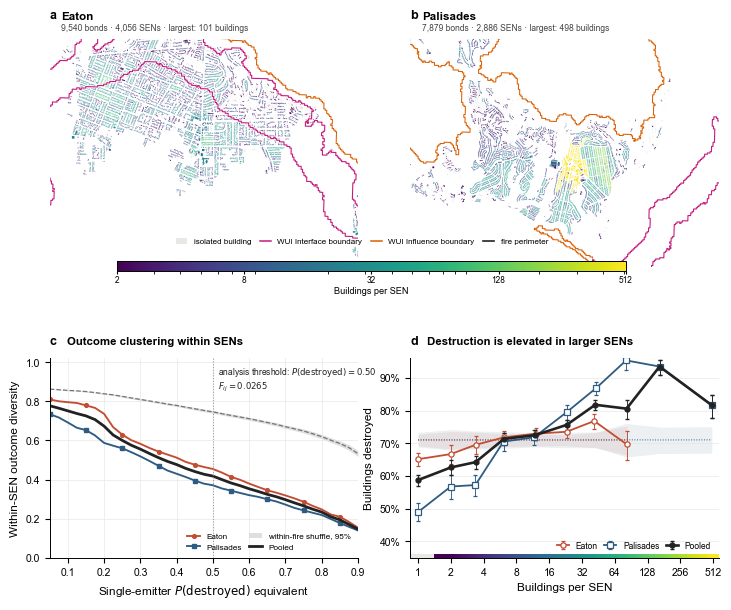

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/main/Fig4_structure_exposure_networks.png


In [6]:
# Use one common palette and component-size scale across both fires and panel d.
SEN_MAP_CMAPS = {fire: 'viridis' for fire in FIRES}
fig = plot_sen_composite(
    states, shared_fate, size_count_summary, F_IJ_THRESHOLD,
    project_root=PROJECT_ROOT, output_dir=FIGURES,
    map_cmaps=SEN_MAP_CMAPS,
)
plt.show()
print('saved', FIGURES / 'Fig4_structure_exposure_networks.png')

In [7]:
import importlib.metadata as metadata
versions = pd.DataFrame({
    'package': ['python', 'numpy', 'pandas', 'geopandas', 'duckdb', 'matplotlib'],
    'version': [sys.version.split()[0]] + [
        metadata.version(name) for name in
        ['numpy', 'pandas', 'geopandas', 'duckdb', 'matplotlib']
    ],
})
display(versions)

,package,version
0,python,3.10.18
1,numpy,2.2.6
2,pandas,2.3.3
3,geopandas,1.1.1
4,duckdb,1.4.3
5,matplotlib,3.9.4
